#**Carga de Datos y Preparación del Entorno Diagnóstico**


In [ ]:
!pip install datasets pandas numpy matplotlib seaborn plotly wordcloud -q


In [ ]:

import io
import gc
import os
import time
import cv2
import warnings
import multiprocessing
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
from PIL import Image
from tqdm import tqdm
from wordcloud import WordCloud
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Librerías importadas correctamente.')

print('Cargando dataset imageomics/rare-species...')
dataset = load_dataset(
    'imageomics/rare-species',
    split='train',
    trust_remote_code=True
)

COLS = ['file_name', 'rarespecies_id', 'eol_content_id', 'eol_page_id',
        'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'sciName', 'common']

df = dataset.to_pandas()[COLS]
print(f'✅ Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(5)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imageomics/rare-species' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imageomics/rare-species' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


✅ Librerías importadas correctamente.
Cargando dataset imageomics/rare-species...


README.md:   0%|          | 0.00/19.5k [00:00<?, ?B/s]

data/train-00000-of-00009.parquet:   0%|          | 0.00/474M [00:00<?, ?B/s]

data/train-00001-of-00009.parquet:   0%|          | 0.00/494M [00:00<?, ?B/s]

...

data/train-00007-of-00009.parquet:   0%|          | 0.00/457M [00:00<?, ?B/s]

data/train-00008-of-00009.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11983 [00:00<?, ? examples/s]

✅ Dataset cargado: 11,983 filas x 13 columnas


,file_name,rarespecies_id,eol_content_id,eol_page_id,kingdom,phylum,class,order,family,genus,species,sciName,common
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,75fd91cb-2881-41cd-88e6-de451e8b60e2,12853737,449393,Animalia,Mollusca,Bivalvia,Unionida,Unionidae,Cyclonaias,tuberculata,Cyclonaias tuberculata,purple wartyback
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,28c508bc-63ff-4e60-9c8f-1934367e1528,20969394,793083,Animalia,Chordata,Reptilia,Testudines,Geoemydidae,Pangshura,sylhetensis,Pangshura sylhetensis,Assam Roofed Turtle
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,00372441-588c-4af8-9665-29bee20822c0,28895411,319982,Animalia,Chordata,Amphibia,Caudata,Cryptobranchidae,Andrias,japonicus,Andrias japonicus,Japanese Giant Salamander
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,29cc6040-6af2-49ee-86ec-ab7d89793828,29658536,45510188,Animalia,Chordata,Aves,Passeriformes,Turdidae,Myadestes,obscurus,Myadestes obscurus,'Oma'o
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,94004bff-3a33-4758-8125-bf72e6e57eab,21252576,7250886,Animalia,Chordata,Mammalia,Primates,Indriidae,Propithecus,deckenii,Propithecus deckenii,Van der Decken's Sifaka


# Índice de Contenidos — Análisis Exploratorio de Datos (EDA)

* ## 1. Diagnóstico Estructural e Integridad del Dataset
* ### 1.1. Análisis Estructural, Tipos y Cardinalidad
* ### 1.2. Análisis de Integridad: Valores Nulos y Duplicados

## 2. Análisis Distribucional de Variables Categóricas
* ### 2.1. Nivel Macro-Taxonómico: Reino y Filo
* ### 2.2. Nivel Meso-Taxonómico: Orden y Familia
* ### 2.3. Nivel Micro-Taxonómico: Clase y Especie
* ### 2.4. Estructura Jerárquica Global (Treemap Taxonómico)
* ### 2.5. Análisis de Coocurrencia y Cruzamiento Taxonómico
* ### 2.6. Análisis Semántico de Nombres Comunes (Nube de Palabras)

## 3. Análisis de Balance de Clases y Representación
* ### 3.1. Diagnóstico Consolidado de Desbalance y Sesgo Biológico
* ### 3.2. Diagnóstico de Espacios de Color y Canales de Imagen
* ### 3.3. Detección Estadística de Valores Atípicos (Criterio de Tukey)

## 4. Análisis de Calidad y Propiedades de las Imágenes
* ### 4.1. Inspección Visual Aleatoria de Muestras Decodificadas
* ### 4.2. Extracción Paralela de Características Métricas Visuales

## 5. Conclusiones, Hallazgos y Resumen del EDA
* ### 5.1. Consola Ejecutiva de Métricas e Indicadores Clave
* ### 5.2. Hoja de Ruta Técnica y Próximos Pasos para Modelado de Deep Learning

# 1. Diagnóstico Estructural e Integridad del Dataset

Esta sección comprende el análisis inicial de la arquitectura de la tabla de datos y la verificación de su calidad técnica. Se evalúan las dimensiones generales, la correspondencia de los tipos de datos y los vectores de completitud para asegurar una base sólida antes de realizar transformaciones.

## 1.1. Análisis Estructural, Tipos y Cardinalidad
Evaluación técnica de las dimensiones del dataset (registros y columnas) junto con la naturaleza de las variables. El cálculo de la cardinalidad permite diferenciar de forma automática las variables que funcionan como identificadores únicos de aquellas que representan categorías biológicas estables.

In [ ]:
print('='*60)
print(f'  Dimensiones: {df.shape[0]:,} registros  |  {df.shape[1]} columnas')
print('='*60)

print('\nTipos de datos:')
print(df.dtypes)

print('\nCardinalidad (valores únicos por columna):')
cardinality = df.drop(columns=['file_name'], errors='ignore').nunique().reset_index()
cardinality.columns = ['Columna', 'Valores Únicos']
cardinality['Tipo'] = cardinality['Valores Únicos'].apply(
    lambda x: 'Identificador' if x > 1000 else 'Categórica'
)
print(cardinality.to_string(index=False))

  Dimensiones: 11,983 registros  |  13 columnas

Tipos de datos:
file_name         object
rarespecies_id    object
eol_content_id    object
eol_page_id       object
kingdom           object
phylum            object
class             object
order             object
family            object
genus             object
species           object
sciName           object
common            object
dtype: object

Cardinalidad (valores únicos por columna):
       Columna  Valores Únicos          Tipo
rarespecies_id           11983 Identificador
eol_content_id           11983 Identificador
   eol_page_id             400    Categórica
       kingdom               1    Categórica
        phylum               5    Categórica
         class              15    Categórica
         order              85    Categórica
        family             202    Categórica
         genus             316    Categórica
       species             385    Categórica
       sciName             400    Categórica
        comm

## 1.2. Análisis de Integridad: Valores Nulos y Duplicados
Identificación y cuantificación de vectores vacíos o registros idénticos repetidos dentro de la base de datos (excluyendo nombres de archivos). Este paso es indispensable para determinar la necesidad de aplicar técnicas de limpieza o imputación que prevengan sesgos en el entrenamiento.

No hay valores nulos.


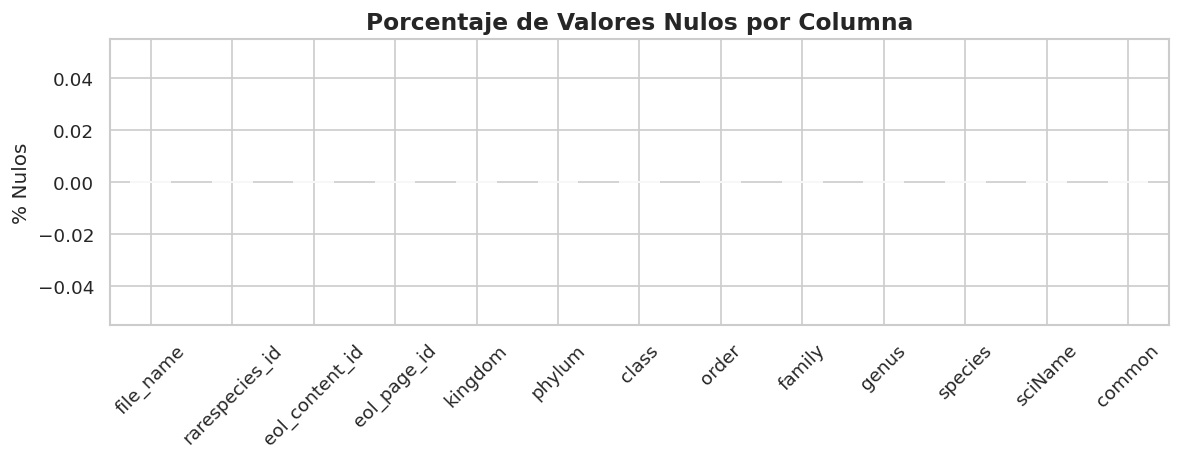


Registros duplicados: 0 (0.00%)


In [ ]:
nulos = df.isnull().sum().reset_index()
nulos.columns = ['Columna', 'Nulos']; nulos['% Nulos'] = (nulos['Nulos'] / len(df) * 100).round(2)

if nulos[nulos['Nulos'] > 0].empty:
    print('No hay valores nulos.')
else:
    print(nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
null_pct = (df.isnull().sum() / len(df) * 100); colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in null_pct]
null_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Porcentaje de Valores Nulos por Columna', fontsize=14, fontweight='bold'); ax.set_ylabel('% Nulos'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

dupes = df.drop(columns=['file_name']).duplicated().sum()
print(f'\nRegistros duplicados: {dupes:,} ({dupes/len(df)*100:.2f}%)')

# 2. Análisis Distribucional de Variables Categóricas

Sección orientada al estudio estadístico y visual de los diferentes niveles de la jerarquía taxonómica presentes en el dataset. Permite comprender cómo se estructuran y dispersan las muestras biológicas en el árbol filogenético.

In [ ]:
def analizar_categorica(df, col, top_n=15, titulo=None):
    conteo = df[col].value_counts().head(top_n); pct = (conteo / len(df) * 100).round(2)
    tabla = pd.DataFrame({'Frecuencia': conteo, '% del Total': pct})

    print(f'\n{"="*55}'); print(f'  Variable: {col.upper()}  |  {df[col].nunique()} categorias unicas'); print(f'{"="*55}')
    print(tabla.to_string()); print(f'  → Moda: "{conteo.index[0]}" con {conteo.iloc[0]:,} registros ({pct.iloc[0]:.1f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5)); titulo_real = titulo or f'Distribucion de {col}'; palette = sns.color_palette('Set2', len(conteo))

    bars = axes[0].barh(conteo.index[::-1], conteo.values[::-1], color=palette[::-1], edgecolor='white')
    axes[0].set_title(f'{titulo_real} — Top {top_n}', fontsize=12, fontweight='bold'); axes[0].set_xlabel('Frecuencia')
    for bar, val in zip(bars, conteo.values[::-1]): axes[0].text(bar.get_width() + max(conteo)*0.01, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)

    show_n = min(8, len(conteo))
    wedges, texts, autotexts = axes[1].pie(conteo.values[:show_n], labels=conteo.index[:show_n], autopct='%1.1f%%', colors=palette[:show_n], startangle=140, pctdistance=0.82)
    for t in autotexts: t.set_fontsize(8)
    axes[1].set_title(f'{titulo_real} — Pastel', fontsize=12, fontweight='bold')

    plt.tight_layout(); plt.show()
    return tabla

## 2.1. Nivel Macro-Taxonómico: Reino y Filo
Examen de las variables de jerarquía superior (`kingdom` y `phylum`). Su análisis sirve para entender la macroestructura de los datos y cuantificar la dominancia de los grandes grupos biológicos dentro del estudio.


  Variable: KINGDOM  |  1 categorias unicas
          Frecuencia  % del Total
kingdom                          
Animalia       11983        100.0
  → Moda: "Animalia" con 11,983 registros (100.0%)


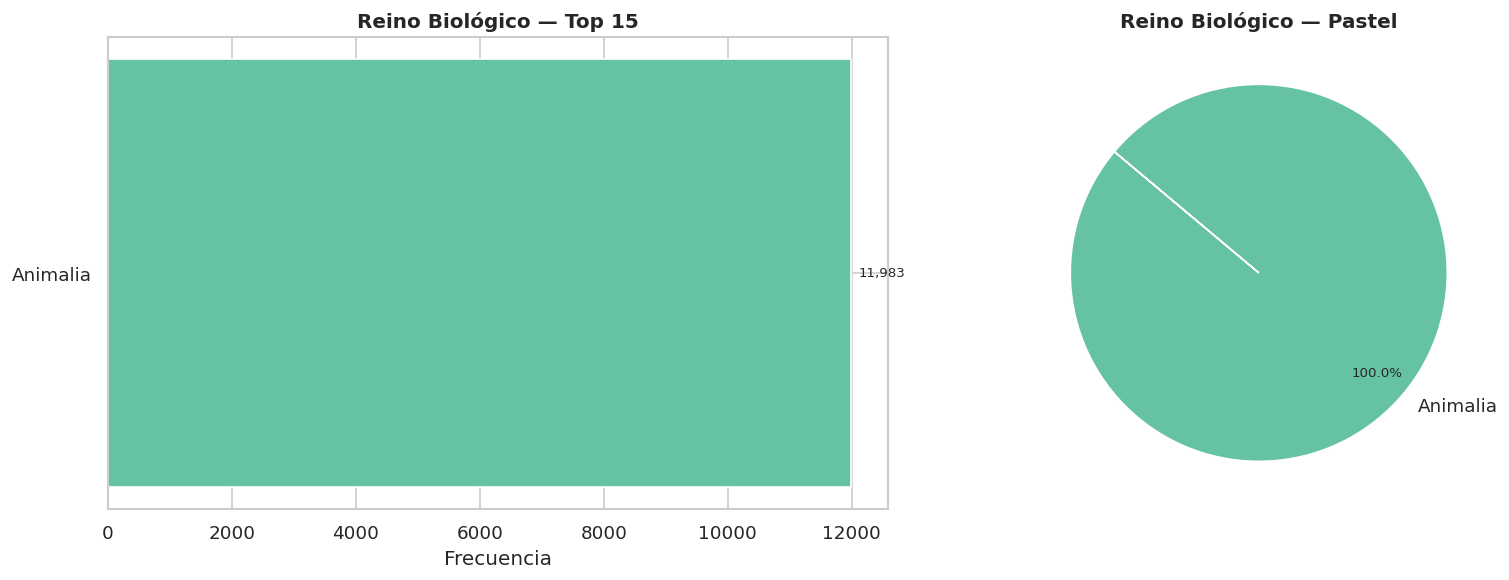

,Frecuencia,% del Total
kingdom,,
Animalia,11983,100.0


In [ ]:
# Kingdom (Reino) — Variable objetivo principal
analizar_categorica(df, 'kingdom', titulo='Reino Biológico')


  Variable: PHYLUM  |  5 categorias unicas
               Frecuencia  % del Total
phylum                                
Chordata             9952        83.05
Arthropoda            951         7.94
Cnidaria              810         6.76
Mollusca              210         1.75
Echinodermata          60         0.50
  → Moda: "Chordata" con 9,952 registros (83.0%)


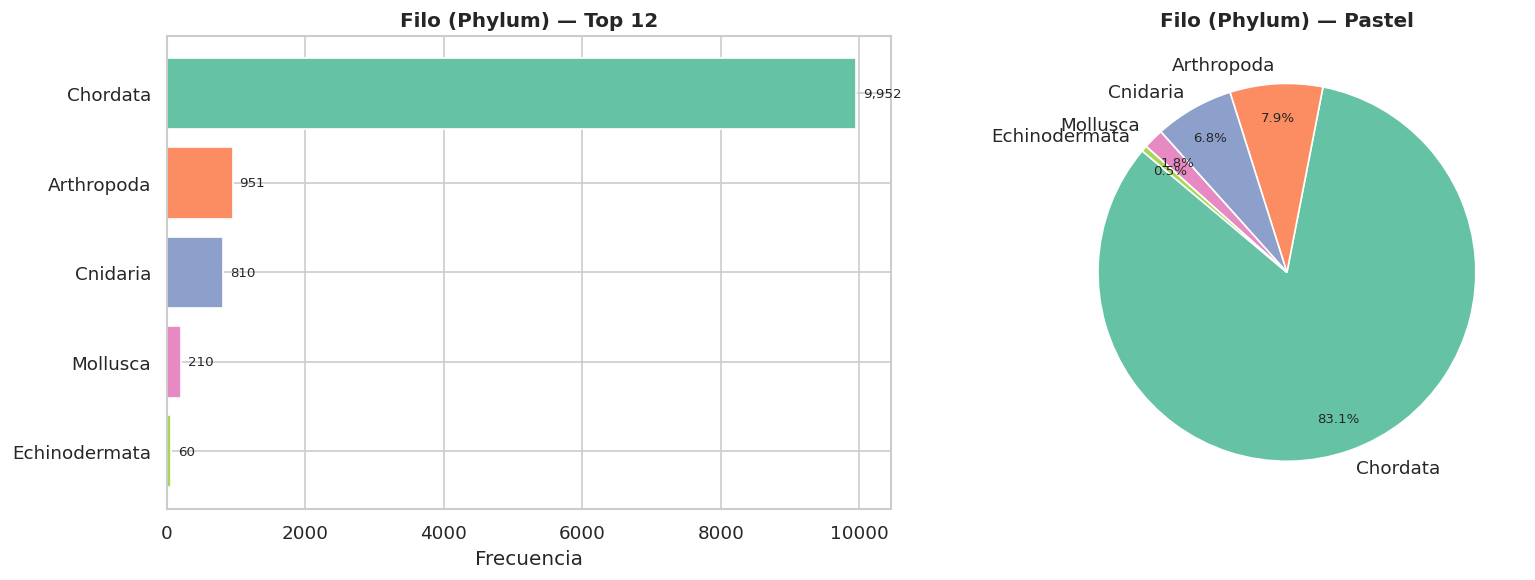

,Frecuencia,% del Total
phylum,,
Chordata,9952,83.05
Arthropoda,951,7.94
Cnidaria,810,6.76
Mollusca,210,1.75
Echinodermata,60,0.50


In [ ]:
# Phylum (Filo)
analizar_categorica(df, 'phylum', top_n=12, titulo='Filo (Phylum)')

## 2.2. Nivel Meso-Taxonómico: Orden y Familia
Evaluación de las variables de nivel intermedio (`order` y `family`). Permite agrupar las categorías biológicas en segmentos morfológicos y evolutivos más amplios que los de una especie aislada.


  Variable: ORDER  |  85 categorias unicas
                   Frecuencia  % del Total
order                                     
Squamata                 1047         8.74
Primates                  990         8.26
Scleractinia              780         6.51
Caudata                   750         6.26
Passeriformes             570         4.76
Anura                     450         3.76
Hymenoptera               441         3.68
Testudines                417         3.48
Charadriiformes           390         3.25
Carcharhiniformes         360         3.00
Myliobatiformes           300         2.50
Artiodactyla              300         2.50
Procellariiformes         270         2.25
Psittaciformes            240         2.00
Carnivora                 240         2.00
  → Moda: "Squamata" con 1,047 registros (8.7%)


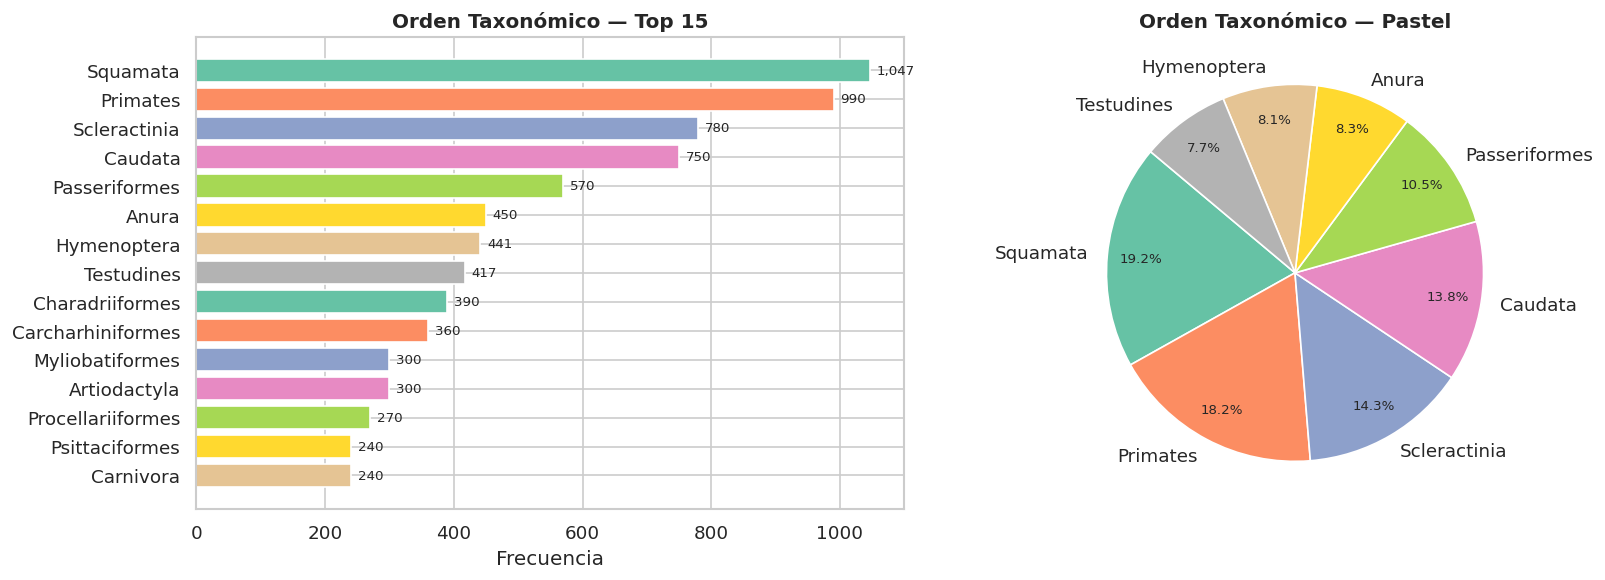

,Frecuencia,% del Total
order,,
Squamata,1047,8.74
Primates,990,8.26
Scleractinia,780,6.51
Caudata,750,6.26
Passeriformes,570,4.76
Anura,450,3.76
Hymenoptera,441,3.68
Testudines,417,3.48
Charadriiformes,390,3.25


In [ ]:
# Order (Orden)
analizar_categorica(df, 'order', top_n=15, titulo='Orden Taxonómico')


  Variable: FAMILY  |  202 categorias unicas
                 Frecuencia  % del Total
family                                  
Dactyloidae             300         2.50
Cercopithecidae         300         2.50
Formicidae              291         2.43
Carcharhinidae          270         2.25
Salamandridae           270         2.25
Plethodontidae          270         2.25
Bovidae                 240         2.00
Bucerotidae             210         1.75
Acroporidae             210         1.75
Diomedeidae             180         1.50
Anatidae                180         1.50
Bufonidae               150         1.25
Atelidae                150         1.25
Laridae                 150         1.25
Apidae                  150         1.25
  → Moda: "Dactyloidae" con 300 registros (2.5%)


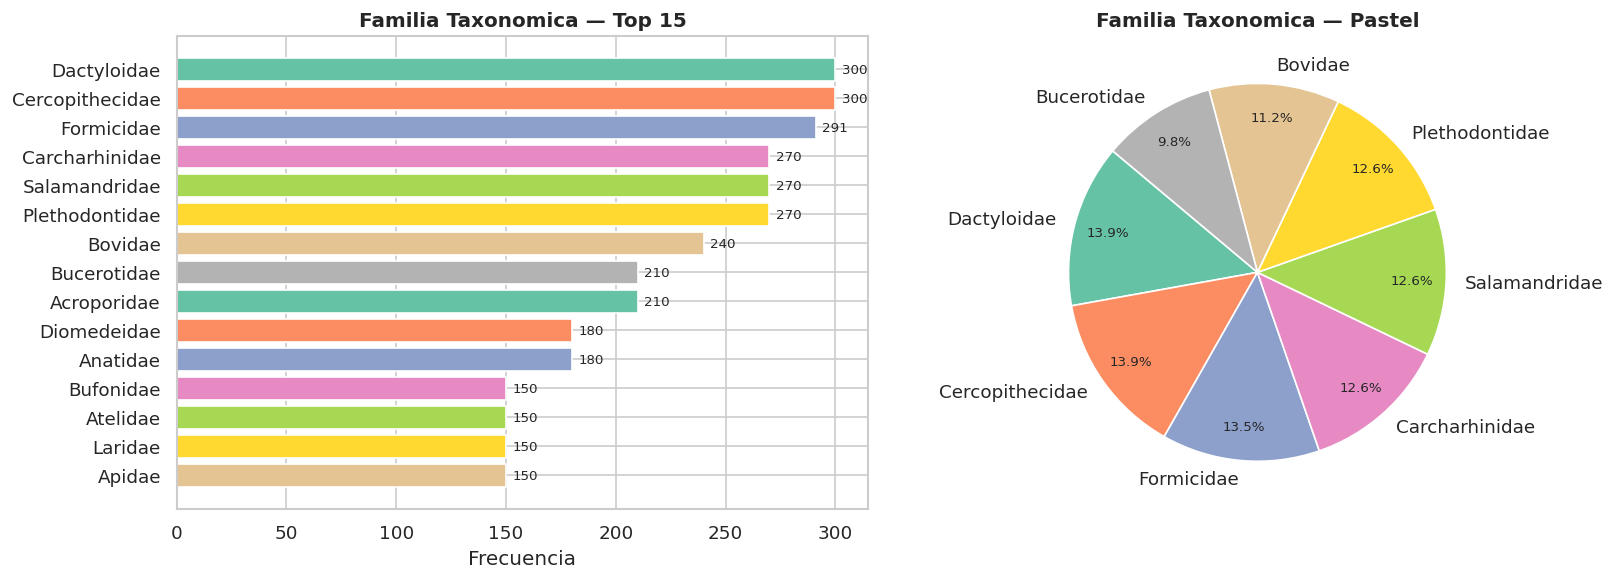

,Frecuencia,% del Total
family,,
Dactyloidae,300,2.50
Cercopithecidae,300,2.50
Formicidae,291,2.43
Carcharhinidae,270,2.25
Salamandridae,270,2.25
Plethodontidae,270,2.25
Bovidae,240,2.00
Bucerotidae,210,1.75
Acroporidae,210,1.75


In [ ]:
#family (Familia)
analizar_categorica(df, 'family', top_n=15, titulo='Familia Taxonomica')

## 2.3. Nivel Micro-Taxonómico: Clase y Especie
Análisis detallado de la variable objetivo del proyecto (`class`) y de la unidad básica biológica (`species`). Monitorea la granularidad del set de datos y la distribución específica de los elementos que el modelo aprenderá a clasificar.


  Variable: CLASS  |  15 categorias unicas
                Frecuencia  % del Total
class                                  
Aves                  2909        24.28
Mammalia              2250        18.78
Reptilia              1584        13.22
Amphibia              1200        10.01
Chondrichthyes        1140         9.51
Actinopterygii         839         7.00
Insecta                831         6.93
Anthozoa               810         6.76
Bivalvia               120         1.00
Gastropoda              90         0.75
Holothuroidea           60         0.50
Arachnida               60         0.50
Coelacanthi             30         0.25
Branchiopoda            30         0.25
Malacostraca            30         0.25
  → Moda: "Aves" con 2,909 registros (24.3%)


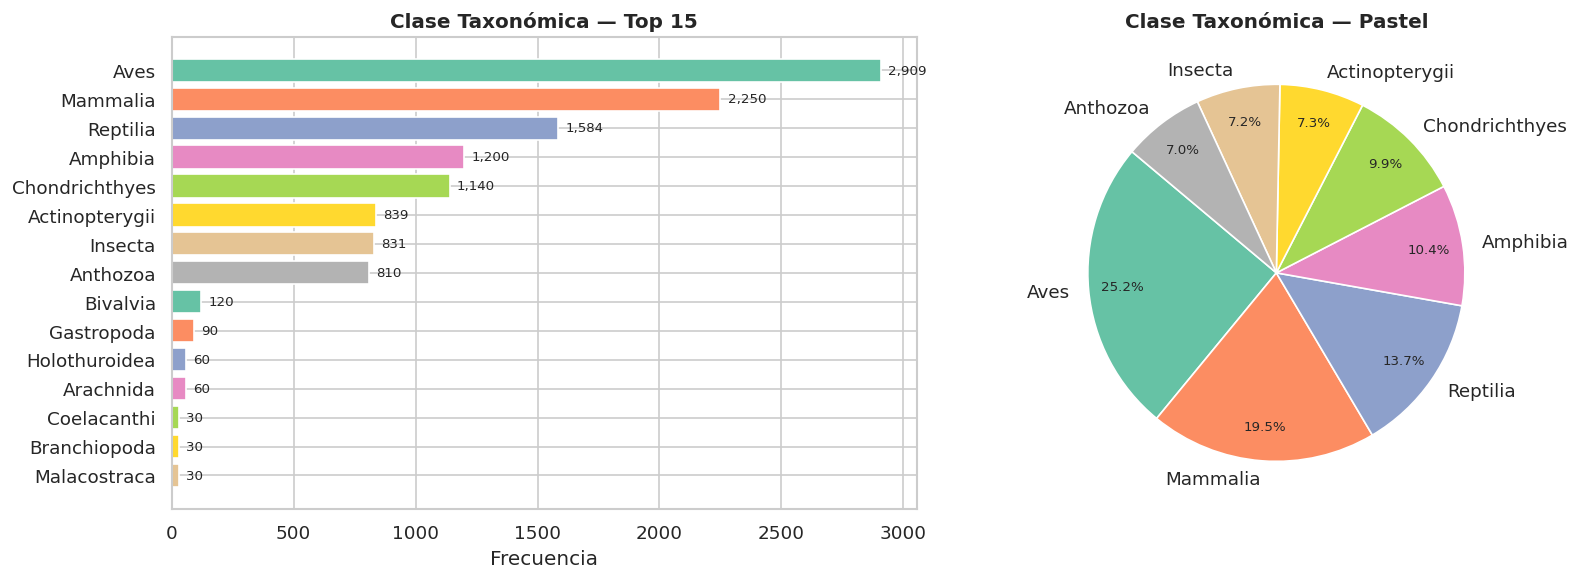

,Frecuencia,% del Total
class,,
Aves,2909,24.28
Mammalia,2250,18.78
Reptilia,1584,13.22
Amphibia,1200,10.01
Chondrichthyes,1140,9.51
Actinopterygii,839,7.00
Insecta,831,6.93
Anthozoa,810,6.76
Bivalvia,120,1.00


In [ ]:
# Class (Clase)
analizar_categorica(df, 'class', top_n=15, titulo='Clase Taxonómica')


  Variable: SPECIES  |  385 categorias unicas
              Frecuencia  % del Total
species                              
gigas                 90         0.75
maximus               90         0.75
rufus                 60         0.50
obscurus              60         0.50
coronatus             60         0.50
kirtlandii            60         0.50
brevirostris          60         0.50
auratus               60         0.50
brasiliensis          60         0.50
cervicornis           60         0.50
davidianus            60         0.50
japonica              60         0.50
barbouri              60         0.50
digitifera            30         0.25
rivularis             30         0.25
  → Moda: "gigas" con 90 registros (0.8%)


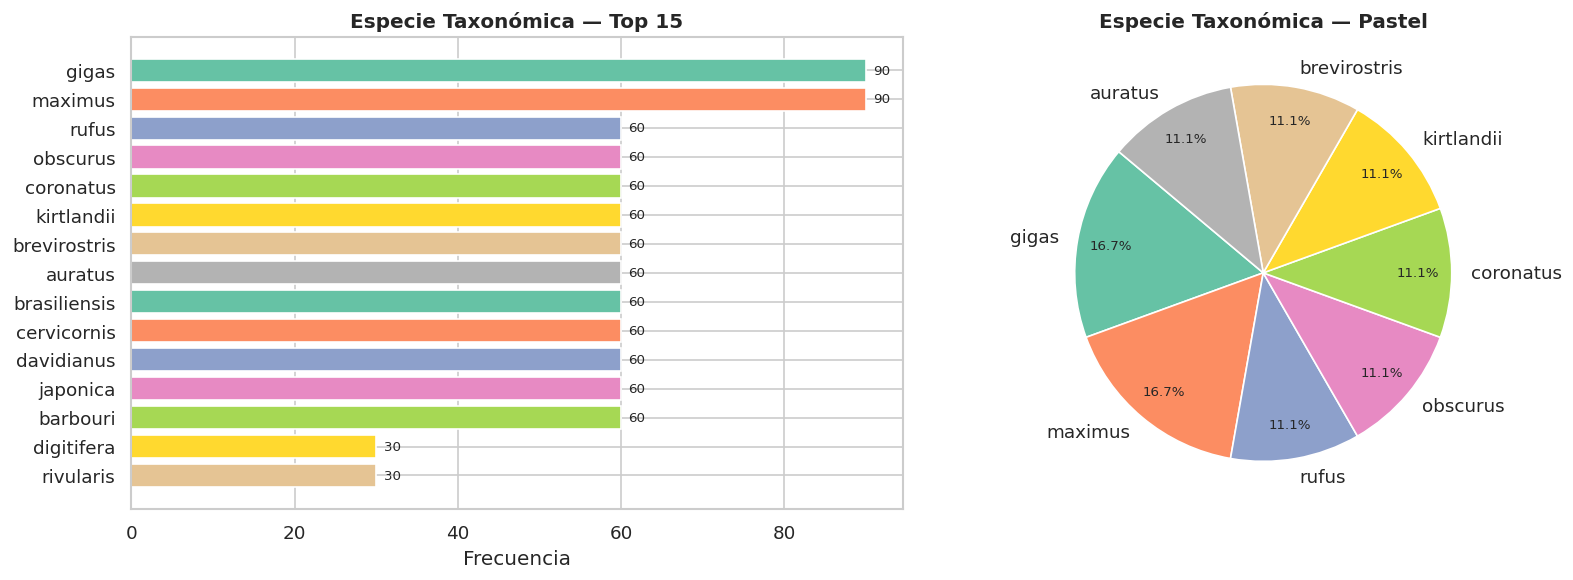

,Frecuencia,% del Total
species,,
gigas,90,0.75
maximus,90,0.75
rufus,60,0.50
obscurus,60,0.50
coronatus,60,0.50
kirtlandii,60,0.50
brevirostris,60,0.50
auratus,60,0.50
brasiliensis,60,0.50


In [ ]:
#species (Especie)
analizar_categorica(df,'species', top_n=15, titulo='Especie Taxonómica')

## 2.4. Estructura Jerárquica Global (Treemap Taxonómico)

Esta subsección integra los diferentes niveles de la jerarquía taxonómica utilizando un gráfico interactivo de tipo Treemap. Esta visualización permite mapear la estructura completa desde el Reino hasta el Orden de forma anidada, facilitando la identificación visual de las ramas taxonómicas más densas y el peso relativo de cada subdivisión biológica en todo el set de datos.

In [ ]:
df_tree = df.groupby(['class', 'order']).size().reset_index(name='count')
fig = px.treemap(df_tree, path=[px.Constant('Todas las Clases'), 'class', 'order'], values='count', color='class', title='Treemap Taxonomico: Class -> Order')
fig.update_layout(height=650);
fig.update_traces(textinfo='label+percent entry');
fig.show()

## 2.5. Análisis de Coocurrencia y Cruzamiento Taxonómico

Esta subsección implementa un mapa de calor (Heatmap) para evaluar la relación bivariada entre las clases taxonómicas principales y los órdenes más frecuentes. Esta matriz de coocurrencia permite validar de manera cruzada la consistencia de las etiquetas biológicas y visualizar la densidad de muestras compartidas, ayudando a detectar agrupaciones lógicas o vacíos de intersección estructural dentro del set de datos.

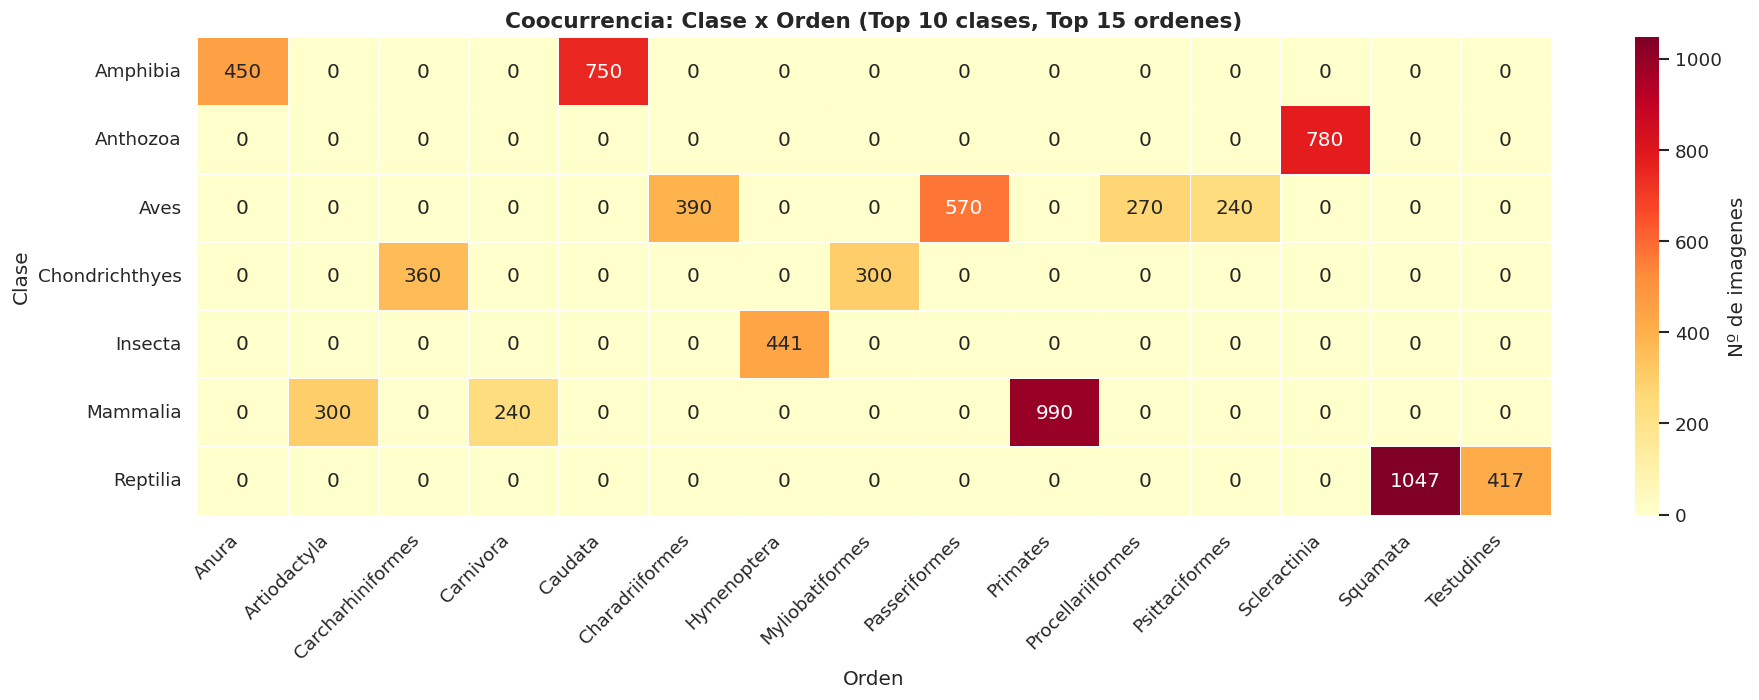

In [ ]:
top_classes = df['class'].value_counts().head(10).index; top_orders = df['order'].value_counts().head(15).index
df_heat = df[df['class'].isin(top_classes) & df['order'].isin(top_orders)]; pivot = pd.crosstab(df_heat['class'], df_heat['order'])

plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'Nº de imagenes'})
plt.title('Coocurrencia: Clase x Orden (Top 10 clases, Top 15 ordenes)', fontsize=13, fontweight='bold')
plt.xlabel('Orden'); plt.ylabel('Clase'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 2.6. Análisis Semántico de Nombres Comunes (Nube de Palabras)

Esta subsección implementa una nube de palabras (WordCloud) basada en las etiquetas de texto de la columna de nombres comunes (`common`). El análisis permite extraer y visualizar de manera inmediata los términos vernáculos o descriptores más recurrentes en el set de datos, aportando una capa interpretativa semántica sobre la naturaleza morfológica o geográfica popular de las muestras biológicas indexadas.

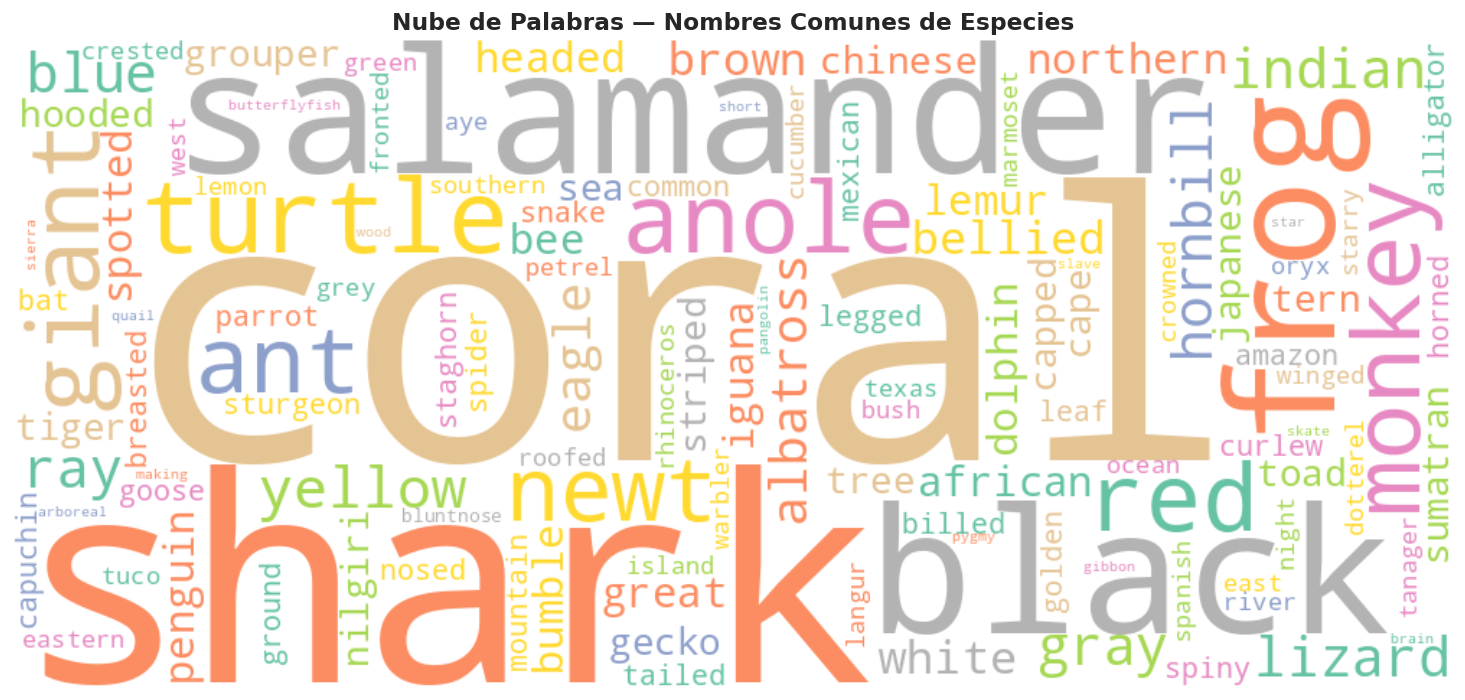

In [ ]:
texto = ' '.join(df['common'].dropna().astype(str).str.lower().tolist())
wc = WordCloud(width=1000, height=450, background_color='white', colormap='Set2', max_words=120, collocations=False).generate(texto)

plt.figure(figsize=(14, 6)); plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title('Nube de Palabras — Nombres Comunes de Especies', fontsize=14, fontweight='bold'); plt.tight_layout(); plt.show()

# 3. Análisis de Balance de Clases y Representación

Esta sección evalúa el nivel de equilibrio del dataset enfocado directamente en la variable objetivo y las macro-categorías superiores. Mediante el cálculo de métricas de dispersión (mediana y rango intercuartílico), frecuencias y ratios de desbalance, se determina el sesgo de representación del set de datos para planificar adecuadamente las estrategias de remuestreo o el pesado en la función de pérdida del modelo.

## 3.1. Diagnóstico Consolidado de Desbalance y Sesgo Biológico
Análisis cuantitativo de la presencia y dominancia de los reinos biológicos y las clases taxonómicas. Permite identificar la concentración extrema de muestras en grupos mayoritarios y medir formalmente el ratio de desbalance crítico en la variable objetivo (`class`).

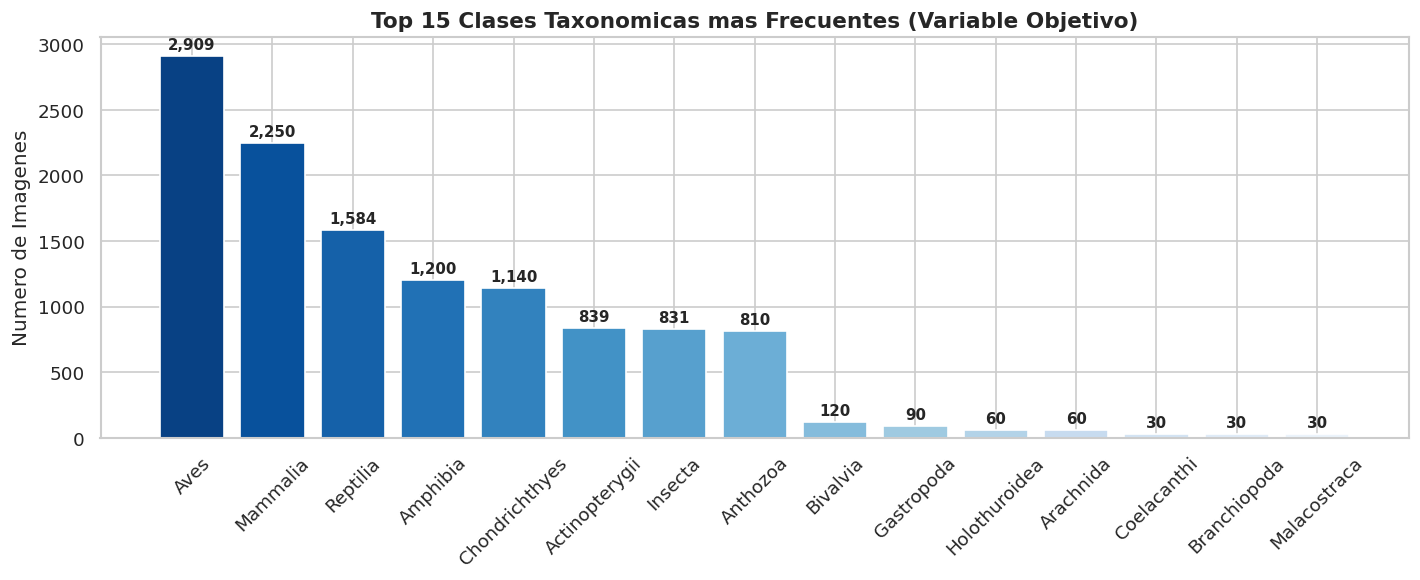


 REPORTES DE SESGO Y DISTRIBUCION DE ETIQUETAS
Estructura de Reinos:
kingdom
Animalia    11983
Ratio desbalance Reinos: 1.0x
------------------------------------------------------------
Resumen de la Variable Objetivo (Clase):
 Total de clases unicas: 15
 Clase mayoritaria: "Aves" con 2,909 imagenes
 Clase minoritaria: "Malacostraca" con 30 imagenes
 Ratio de desbalance critico en Clases: 97.0x


In [ ]:
clases_conteo = df['class'].value_counts()
kingdom_conteo = df['kingdom'].value_counts()
ratio_k = kingdom_conteo.max() / kingdom_conteo.min()
ratio_c = clases_conteo.max() / clases_conteo.min()

palette = sns.color_palette('Blues_r', len(clases_conteo[:15]))
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(clases_conteo.index[:15], clases_conteo.values[:15], color=palette, edgecolor='white')
ax.set_title('Top 15 Clases Taxonomicas mas Frecuentes (Variable Objetivo)', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero de Imagenes'); ax.tick_params(axis='x', rotation=45)

offset = max(clases_conteo.values[:15]) * 0.01
for bar in bars: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset, f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

print('\n' + '='*60); print(' REPORTES DE SESGO Y DISTRIBUCION DE ETIQUETAS'); print('='*60)
print(f'Estructura de Reinos:\n{kingdom_conteo.to_string()}\nRatio desbalance Reinos: {ratio_k:.1f}x')
print('-'*60)
print(f'Resumen de la Variable Objetivo (Clase):\n Total de clases unicas: {len(clases_conteo)}')
print(f' Clase mayoritaria: "{clases_conteo.index[0]}" con {clases_conteo.iloc[0]:,} imagenes')
print(f' Clase minoritaria: "{clases_conteo.index[-1]}" con {clases_conteo.iloc[-1]:,} imagenes')
print(f' Ratio de desbalance critico en Clases: {ratio_c:.1f}x')

## 3.2. Diagnóstico de Espacios de Color y Canales de Imagen (Integridad de Tensores)

Esta subsección analiza la distribución de los modos de color (`modo`) extraídos de los metadatos binarios de las imágenes (como RGB, RGBA, L o P). Identificar la presencia de imágenes con canales de transparencia (alfa) o en escala de grises es un paso crítico en el pipeline de preprocesamiento, ya que permite diseñar las transformaciones de tipificado estricto necesarias para evitar inconsistencias en las dimensiones de los tensores durante el entrenamiento de la red neuronal convolucional.

Distribucion de Modos de Color detectados:
RGB     11622
L         183
CMYK      178


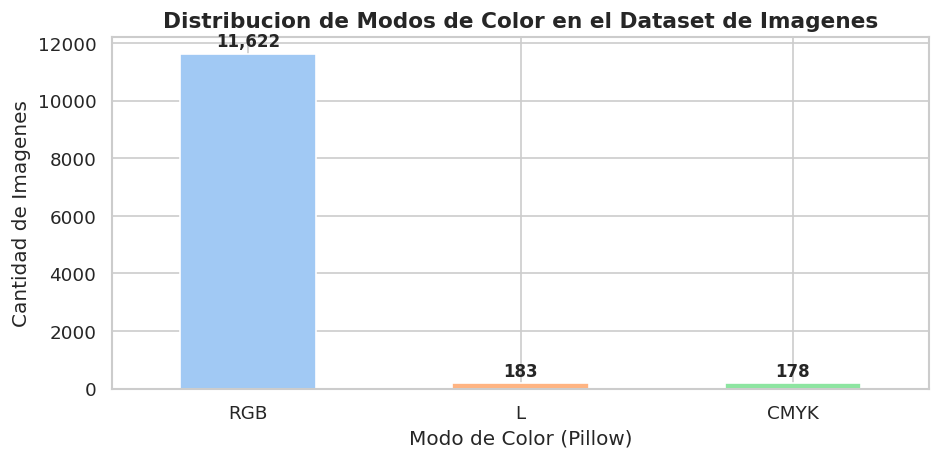

In [ ]:
def obtener_modos_rapido(df):
    modos = []
    for idx, row in df.iterrows():
        try:
            img = Image.open(io.BytesIO(row['file_name']['bytes']))
            modos.append(img.mode)
        except Exception:
            modos.append('Corrupta/No leida')
    return pd.Series(modos)

# Se extraen los modos directamente sin depender de la seccion 4
modo_conteo = obtener_modos_rapido(df).value_counts()
print('Distribucion de Modos de Color detectados:'); print(modo_conteo.to_string())

fig, ax = plt.subplots(figsize=(8, 4)); palette = sns.color_palette('pastel', len(modo_conteo))
modo_conteo.plot(kind='bar', ax=ax, color=palette, edgecolor='white')
ax.set_title('Distribucion de Modos de Color en el Dataset de Imagenes', fontsize=13, fontweight='bold')
ax.set_xlabel('Modo de Color (Pillow)'); ax.set_ylabel('Cantidad de Imagenes'); ax.tick_params(axis='x', rotation=0)

for bar in ax.patches: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(modo_conteo.values)*0.01), f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

## 3.3. Detección Estadística de Valores Atípicos (Criterio de Tukey)

Esta subsección aplica el método matemático de Rango Intercuartílico (IQR) bajo el criterio de Tukey para identificar formalmente aquellas clases taxonómicas que presentan un volumen de imágenes anómalo. El análisis detecta tanto clases hiper-representadas (por encima del límite superior) como críticamente desabastecidas (por debajo del límite inferior), lo cual resulta indispensable para guiar los umbrales de truncamiento o las técnicas de aumentación de datos selectiva.

In [ ]:
imgs_clase = df['class'].value_counts()
Q1, Q3 = imgs_clase.quantile(0.25), imgs_clase.quantile(0.75); IQR = Q3 - Q1
lim_sup, lim_inf = Q3 + 1.5 * IQR, Q1 - 1.5 * IQR

outliers_sup = imgs_clase[imgs_clase > lim_sup]; outliers_inf = imgs_clase[imgs_clase < lim_inf]

print(f'Q1={Q1:.0f} | Q3={Q3:.0f} | IQR={IQR:.0f}')
print(f'Limite superior: {lim_sup:.0f}  |  Limite inferior: {lim_inf:.0f}')
print(f'\nClases con DEMASIADAS imagenes ({len(outliers_sup)}):'); print(outliers_sup.head(10).to_string())
print(f'\nClases con MUY POCAS imagenes ({len(outliers_inf)}):'); print(outliers_inf.head(10).to_string())

fig = px.box(y=imgs_clase.values, points='outliers', title='Boxplot — Imagenes por Clase (Outliers)', labels={'y': 'N° de imagenes'}, color_discrete_sequence=['#27ae60'])
fig.update_layout(height=450); fig.show()

Q1=60 | Q3=1170 | IQR=1110
Limite superior: 2835  |  Limite inferior: -1605

Clases con DEMASIADAS imagenes (1):
class
Aves    2909

Clases con MUY POCAS imagenes (0):
Series([], )


# 4. Análisis de Calidad y Propiedades de las Imágenes

Esta sección comprende el diagnóstico técnico de los archivos binarios del dataset. El análisis combina una inspección cualitativa inicial mediante el renderizado de muestras y una auditoría cuantitativa masiva procesada en paralelo para extraer propiedades físicas y estéticas de los mapas de bits.

## 4.1. Inspección Visual Aleatoria de Muestras Decodificadas
Muestreo aleatorio y renderizado en cuadrícula (Grid) de las imágenes almacenadas en formato de bytes. Este paso funciona como un primer filtro de control de calidad para asegurar que las librerías gráficas decodifiquen correctamente las estructuras de compresión y validar la correspondencia con las etiquetas biológicas.

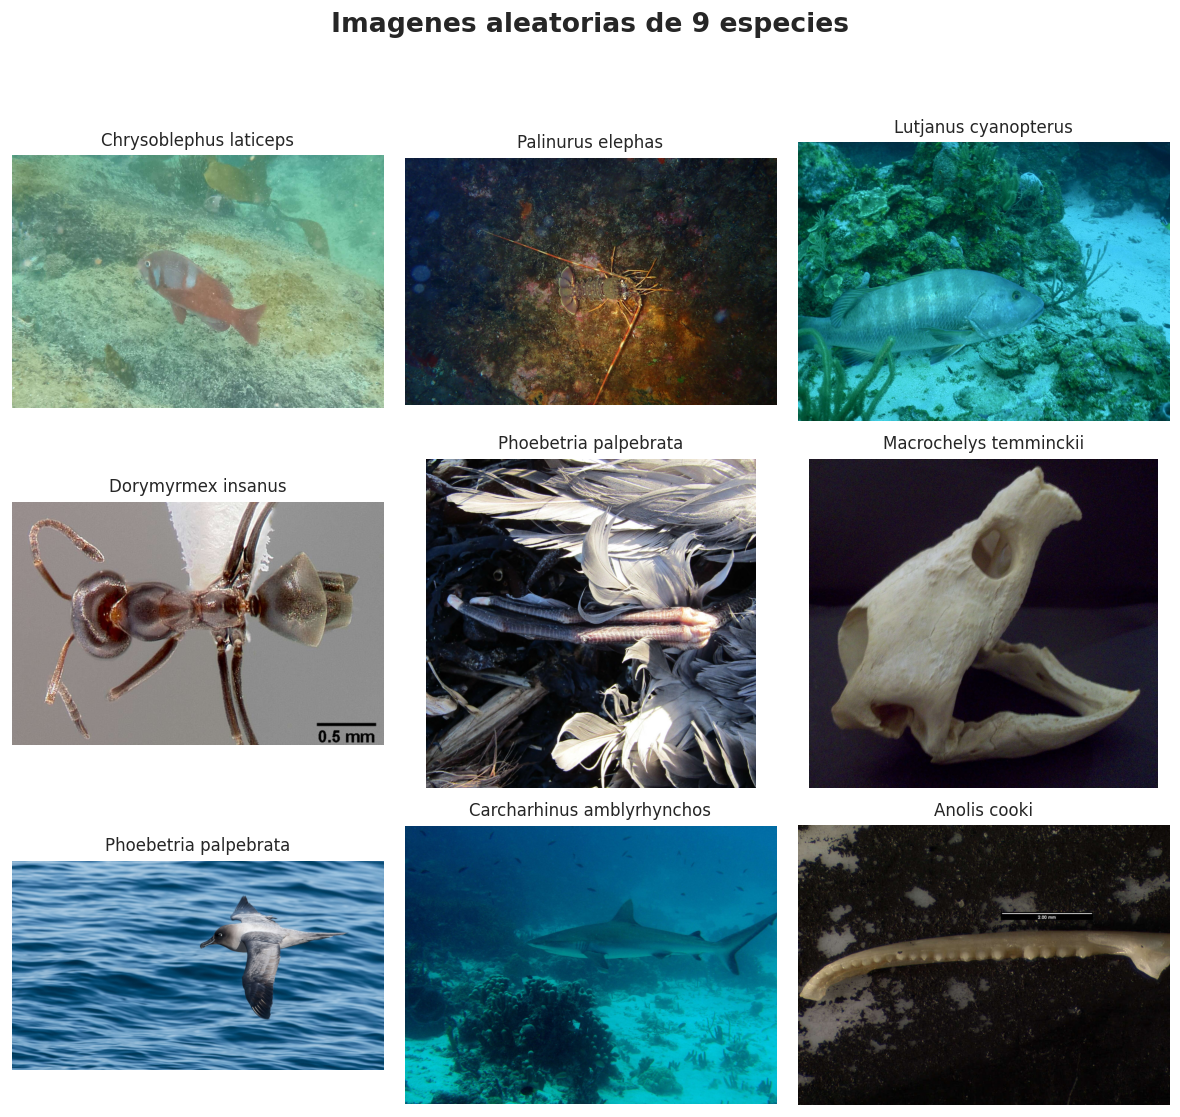

In [ ]:
def plot_random_images(df, num_images=9):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10)); axes = axes.flatten()
    random_samples = df.sample(n=num_images)
    for i, (idx, row) in enumerate(random_samples.iterrows()):
        try:
            image_bytes = row['file_name']['bytes']; image = Image.open(io.BytesIO(image_bytes))
            axes[i].imshow(image); axes[i].set_title(row['sciName'], fontsize=10); axes[i].axis('off')
        except Exception as e:
            axes[i].set_title(f"Error: {e}", fontsize=8); axes[i].axis('off')
            print(f"Error al cargar la imagen {row['sciName']}: {e}")
    plt.suptitle(f'Imagenes aleatorias de {num_images} especies', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

plot_random_images(df, num_images=9)

## 4.2. Extracción Paralela de Características Métricas Visuales
Pipeline de ingeniería de características procesado mediante paralelismo multidireccional en CPU. Se extraen masivamente los metadatos numéricos intrínsecos de cada imagen (ancho, alto, relación de aspecto, brillo, contraste y nitidez por Laplaciano) para diagnosticar estadísticamente la calidad fotográfica y la homogeneidad del set de datos antes del entrenamiento.

In [ ]:
_shared_df = None

def init_worker(dataframe):
    global _shared_df; _shared_df = dataframe

def evaluar_imagen_parallel(i):
    resultado = {'idx': i, 'ancho': None, 'alto': None, 'ratio': None, 'brillo': None, 'contraste': None, 'nitidez': None, 'modo': None, 'es_cuadrada': False}
    try:
        image_bytes = _shared_df.loc[i, 'file_name']['bytes']
        img = Image.open(io.BytesIO(image_bytes))
        resultado['modo'] = img.mode; img = img.convert('RGB')
        w, h = img.size; resultado['ancho'], resultado['alto'] = w, h
        resultado['ratio'] = round(w / h, 3); resultado['es_cuadrada'] = (0.95 <= w/h <= 1.05)
        arr = np.array(img); gris = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        resultado['brillo'], resultado['contraste'] = float(gris.mean()), float(gris.std())
        resultado['nitidez'] = float(cv2.Laplacian(gris, cv2.CV_64F).var())
        del arr, gris, img
    except Exception:
        pass
    return resultado

resultados_parallel, image_indices = [], list(range(len(df)))
print(f"Evaluando {len(df):,} imagenes con paralelismo...")
t0_parallel = time.time()
num_processes = os.cpu_count() - 1 if os.cpu_count() and os.cpu_count() > 1 else 1
print(f"Usando {num_processes} procesos para paralelizar.")
chunksize = 100

if num_processes > 0:
    with multiprocessing.Pool(processes=num_processes, initializer=init_worker, initargs=(df,)) as pool:
        for result in tqdm(pool.imap_unordered(evaluar_imagen_parallel, image_indices, chunksize=chunksize), total=len(image_indices), desc="Evaluando en paralelo"):
            resultados_parallel.append(result)
else:
    print("No se pueden crear procesos paralelos, ejecutando secuencialmente.")
    for i in tqdm(image_indices, desc="Evaluando secuencialmente"):
        _shared_df = df; resultados_parallel.append(evaluar_imagen_parallel(i))

gc.collect(); df_eval_parallel = pd.DataFrame(resultados_parallel)
print(f"Completado en {time.time()-t0_parallel:.0f}s")
display(df_eval_parallel.head(3))

Evaluando 11,983 imagenes con paralelismo...
Usando 1 procesos para paralelizar.


Evaluando en paralelo: 100%|██████████| 11983/11983 [17:05<00:00, 11.68it/s]


Completado en 1027s


,idx,ancho,alto,ratio,brillo,contraste,nitidez,modo,es_cuadrada
0,0,400,400,1.000,101.645313,32.779471,3219.593444,RGB,True
1,1,1596,1066,1.497,168.982406,39.121761,115.771438,RGB,False
2,2,2480,1396,1.777,57.684533,66.928274,207.646137,RGB,False


# 5. Conclusiones, Hallazgos y Resumen del EDA

Esta sección consolida de forma ejecutiva los indicadores clave de rendimiento, la integridad estructural y las características jerárquicas descubiertas a lo largo del análisis exploratorio. El sumario automatiza la extracción de vectores críticos y establece formalmente la hoja de ruta técnica para la fase de preprocesamiento, aumentación selectiva y configuración arquitectónica del modelo de aprendizaje profundo.

## 5.1. Consola Ejecutiva de Métricas e Indicadores Clave
Reporte integrado que unifica las dimensiones del dataset, vectores de completitud y cardinalidad de todas las jerarquías taxonómicas para ofrecer un estado del arte inmediato del set de datos.

## 5.2. Hoja de Ruta Técnica y Próximos Pasos para Modelado de Deep Learning
Directrices estratégicas basadas en la evidencia empírica del análisis para mitigar el desbalance, preprocesar los canales binarios y proponer la arquitectura de red neuronal idónea para el proyecto.

In [ ]:
print('='*65); print('  RESUMEN EDA — imageomics/rare-species'); print('='*65)

print('\n5.1. CONSOLA EJECUTIVA DE METRICAS E INDICADORES CLAVE')
print('-'*65)
print(f'📌 STRUCTURE DEL DATASET')
print(f'  Registros : {len(df):,}'); print(f'  Columnas  : {df.shape[1]}')
print(f'  Nulos     : {df.isnull().sum().sum()}')
print(f'  Duplicados: {df.drop(columns=["file_name"], errors="ignore").duplicated().sum()}')

print(f'\n📌 JERARQUIA TAXONOMICA COMPLETA')
for col in ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']:
    n = df[col].nunique(); moda = df[col].mode()[0]; pct = df[col].value_counts().iloc[0] / len(df) * 100
    print(f'  {col:10s}: {n:>5,} unicos | moda="{moda}" ({pct:.1f}%)')

print(f'\n📌 VARIABLE OBJETIVO (CLASE) — DETALLES')
v = df['class'].value_counts()
print(f'  Mediana : {v.median():.0f}'); print(f'  IQR     : {v.quantile(0.25):.0f} – {v.quantile(0.75):.0f}'); print(f'  Rango   : {v.min()} – {v.max()}')

print('\n' + '-'*65)
print('5.2. HOJA DE RUTA TECNICA Y PROXIMOS PASOS (DEEP LEARNING)')
print('-'*65)
print('📌 CONCLUSIONES Y HALLAZGOS CRITICOS')
print('  1. El dataset esta dominado de forma absoluta por el reino Animalia.')
print('  2. Existe un fuerte desbalance entre clases, lo que puede inducir sesgo algoritmico.')
print('  3. Multiples clases presentan un volumen critico muy bajo de muestras fotograficas.')
print('  4. Las jerarquias inferiores (orden, familia, genero) son viables como caracteristicas auxiliares.')

print(f'\n📌 ACCIONES RECOMENDADAS PARA EL PIPELINE')
print('  -> Implementar aumento de datos estricto (Data Augmentation) enfocado en clases minoritarias.')
print('  -> Configurar pesos de clase (Class Weights) o tecnicas de sobremuestreo en la funcion de perdida.')
print('  -> Utilizar Transfer Learning mediante arquitecturas eficientes en extraccion (EfficientNet o ViT).')
print('='*65)

  RESUMEN EDA — imageomics/rare-species

📌 DATASET
  Registros : 11,983
  Columnas  : 13
  Nulos     : 0
  Duplicados: 0

📌 JERARQUIA TAXONOMICA
  kingdom   :     1 unicos | moda="Animalia" (100.0%)
  phylum    :     5 unicos | moda="Chordata" (83.1%)
  class     :    15 unicos | moda="Aves" (24.3%)
  order     :    85 unicos | moda="Squamata" (8.7%)
  family    :   202 unicos | moda="Cercopithecidae" (2.5%)
  genus     :   316 unicos | moda="Anolis" (2.5%)
  species   :   385 unicos | moda="gigas" (0.8%)

📌 VARIABLE OBJETIVO — imagenes por clase
  Mediana : 810
  IQR     : 60 – 1170
  Rango   : 30 – 2909

📌 CONCLUSIONES Y HALLAZGOS
  1. El dataset esta dominado por el reino Animalia.
  2. Hay desbalance entre clases -> riesgo de sesgo en el modelo al agrupar en este orden taxonomico.
  3. Algunas clases tienen muy pocas imagenes -> aplicar aumento de datos.
  4. La jerarquia taxonomica inferior (como orden, familia, genero) puede usarse como caracteristicas auxiliares.

📌 PROXIMOS PAS